First 5 rows:
        Date  VIC_stringency  NSW_stringency  VIC_unemployment  \
0 2016-02-01             0.0             0.0          6.186083   
1 2016-03-01             0.0             0.0          5.996102   
2 2016-04-01             0.0             0.0          5.676283   
3 2016-05-01             0.0             0.0          5.684920   
4 2016-06-01             0.0             0.0          5.395598   

   NSW_unemployment  
0          5.624091  
1          5.436768  
2          5.130524  
3          5.034129  
4          5.034800  

Column names:
Index(['Date', 'VIC_stringency', 'NSW_stringency', 'VIC_unemployment',
       'NSW_unemployment'],
      dtype='str')

Dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 121 entries, 0 to 120
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Date              121 non-null    datetime64[us]
 1   VIC_stringency    121 non-null    float64       


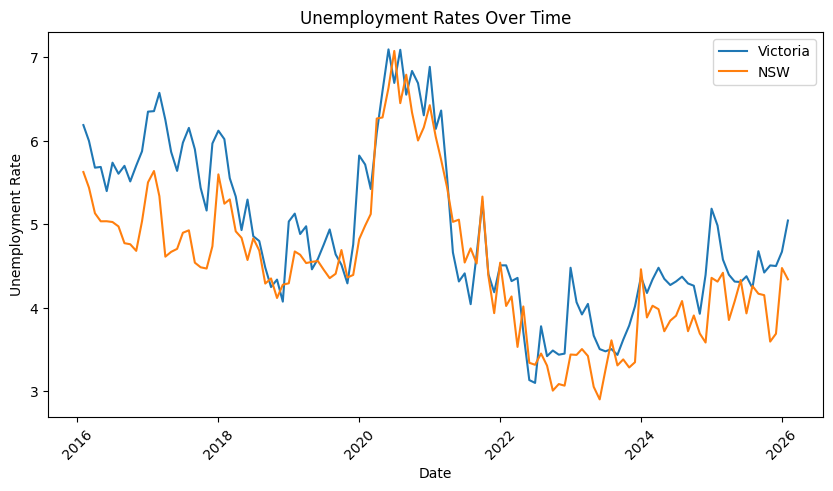

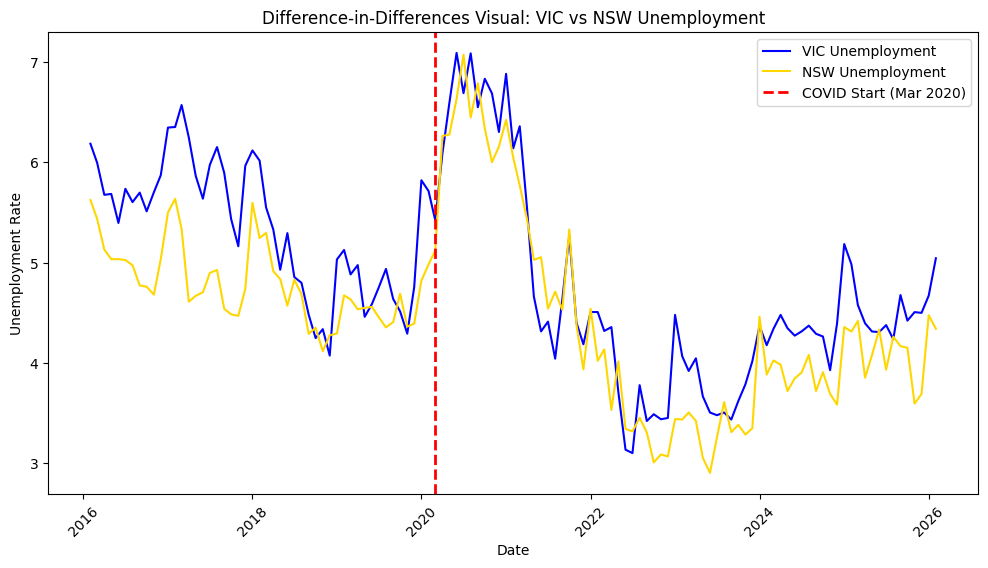

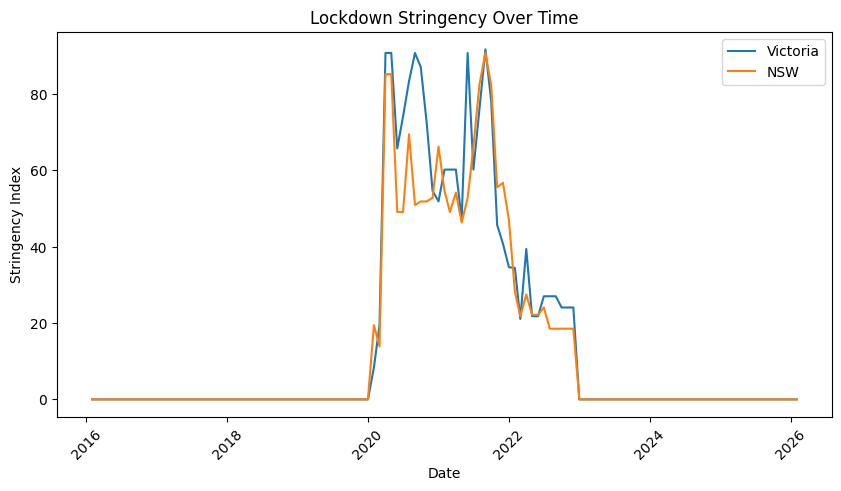

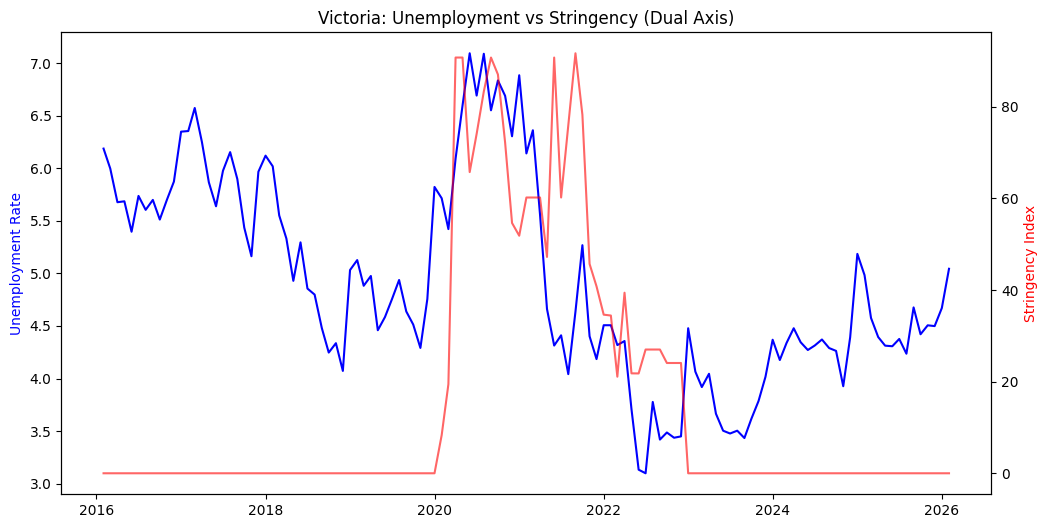

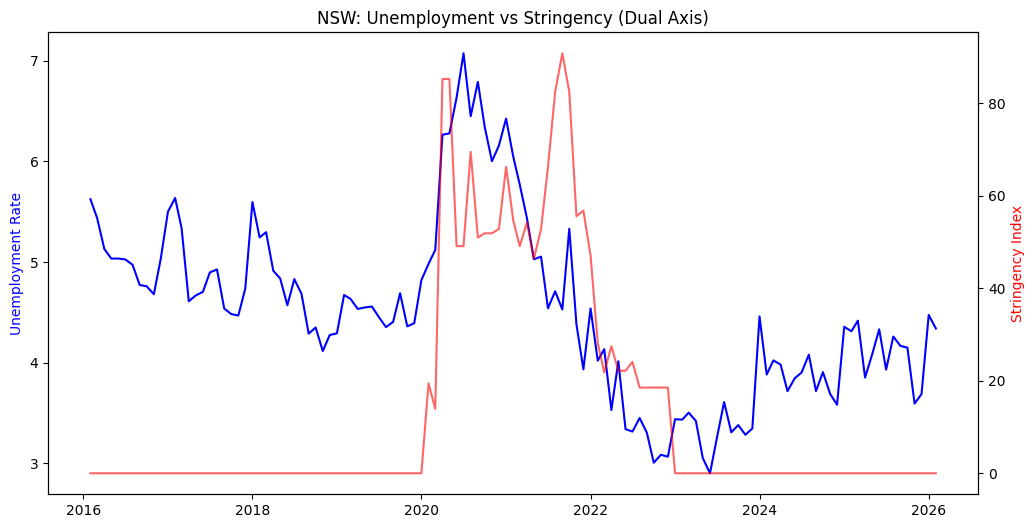

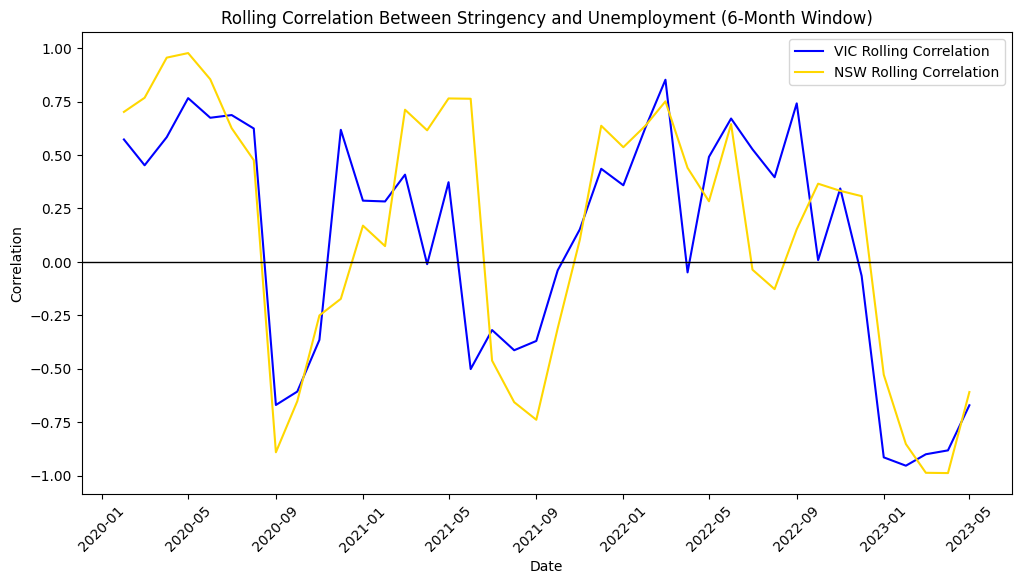

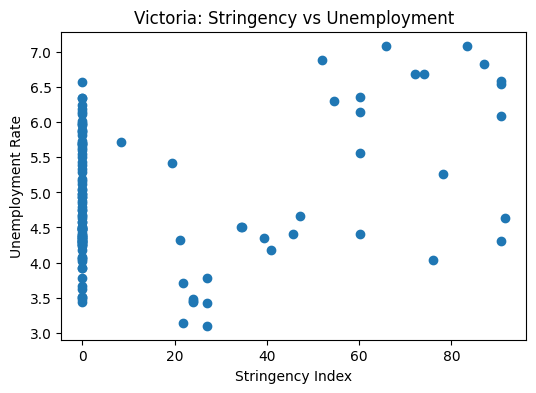

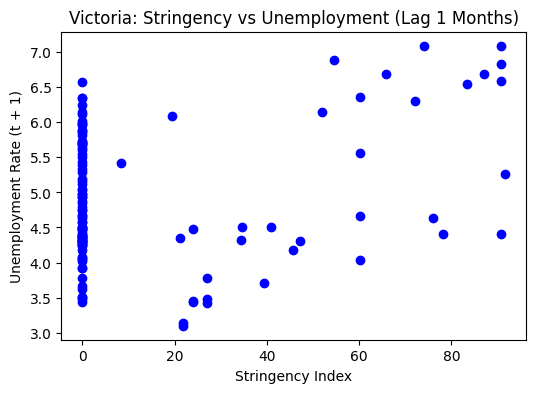

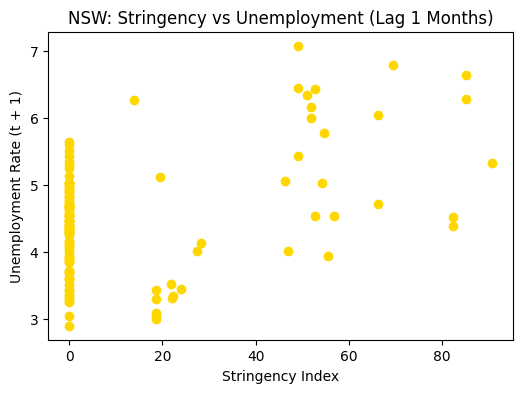

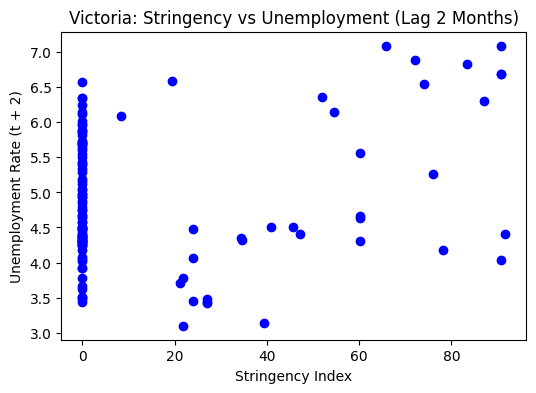

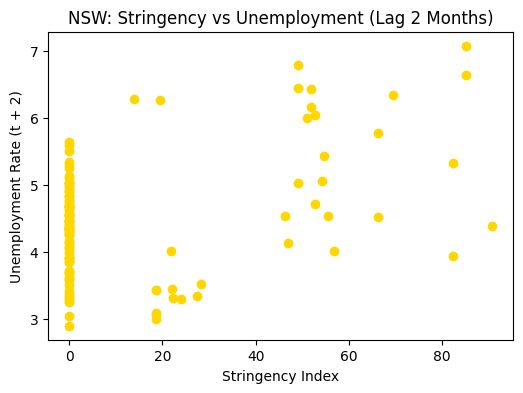

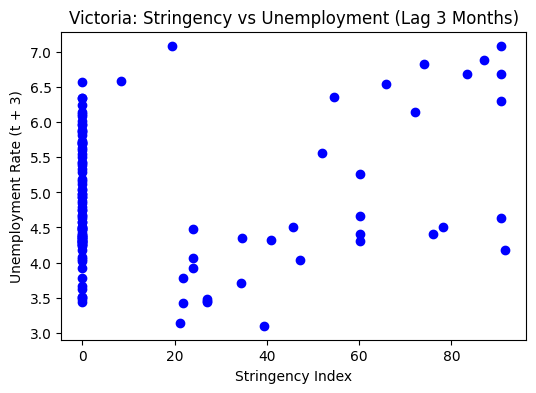

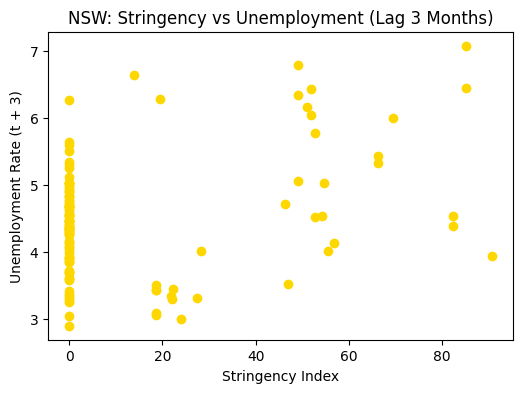


Correlation Matrix:
                  VIC_unemployment  VIC_stringency  NSW_unemployment  \
VIC_unemployment          1.000000        0.303031          0.901256   
VIC_stringency            0.303031        1.000000          0.522594   
NSW_unemployment          0.901256        0.522594          1.000000   
NSW_stringency            0.259254        0.963535          0.475581   

                  NSW_stringency  
VIC_unemployment        0.259254  
VIC_stringency          0.963535  
NSW_unemployment        0.475581  
NSW_stringency          1.000000  


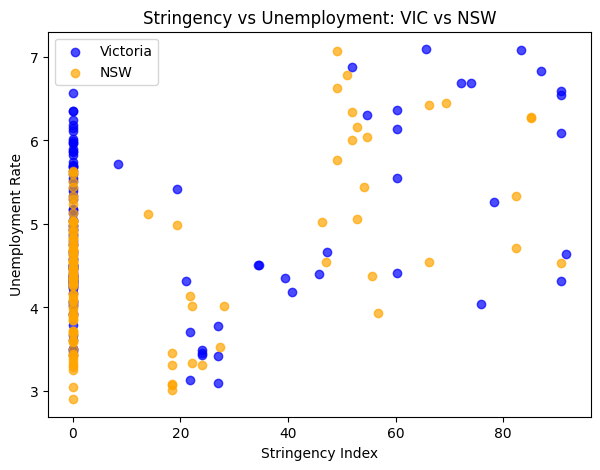

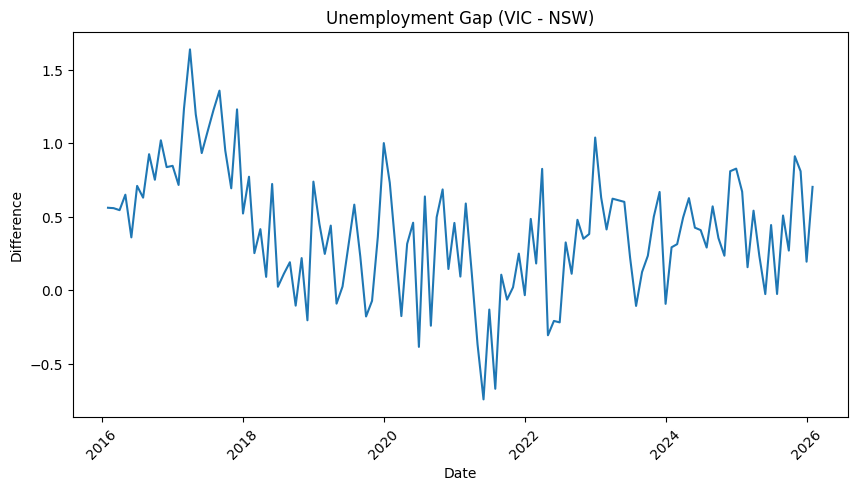

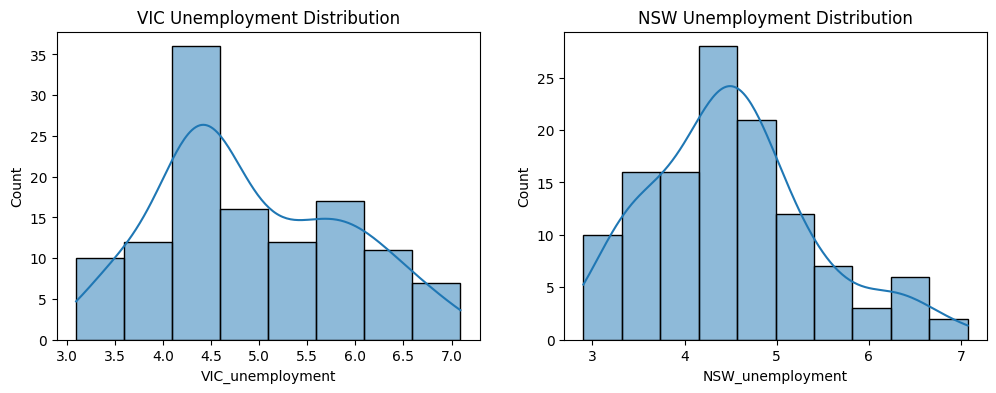

Pre-COVID correlation:
                  VIC_unemployment  VIC_stringency  NSW_unemployment  \
VIC_unemployment          1.000000        0.076709          0.762057   
VIC_stringency            0.076709        1.000000          0.073225   
NSW_unemployment          0.762057        0.073225          1.000000   
NSW_stringency            0.076709        1.000000          0.073225   

                  NSW_stringency  
VIC_unemployment        0.076709  
VIC_stringency          1.000000  
NSW_unemployment        0.073225  
NSW_stringency          1.000000  

Post-COVID correlation:
                  VIC_unemployment  VIC_stringency  NSW_unemployment  \
VIC_unemployment          1.000000        0.648065          0.940466   
VIC_stringency            0.648065        1.000000          0.768720   
NSW_unemployment          0.940466        0.768720          1.000000   
NSW_stringency            0.581716        0.955637          0.707765   

                  NSW_stringency  
VIC_unemployment    

In [2]:
# =========================
# IMPORT LIBRARIES
# =========================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# LOAD DATA
# =========================
df = pd.read_csv('../data/clean/merged_stringency_unemployment.csv')

# Fix column names
df = df.rename(columns={
    'VIC_Unemployment': 'VIC_unemployment',
    'NSW_Unemployment': 'NSW_unemployment',
    'VIC_Stringency': 'VIC_stringency',
    'NSW_Stringency': 'NSW_stringency'
})

# Convert Date BEFORE printing info (this fixes your "FIX THIS")
df['Date'] = pd.to_datetime(df['Date'])

# =========================
# BASIC DATA INSPECTION
# =========================
print("First 5 rows:")
print(df.head())

print("\nColumn names:")
print(df.columns)

print("\nDataset info:")
print(df.info())

print("\nSummary statistics:")
print(df.describe())

# =========================
# TIME SERIES: UNEMPLOYMENT
# =========================
plt.figure(figsize=(10,5))
plt.plot(df['Date'], df['VIC_unemployment'], label='Victoria')
plt.plot(df['Date'], df['NSW_unemployment'], label='NSW')
plt.title('Unemployment Rates Over Time')
plt.xlabel('Date')
plt.ylabel('Unemployment Rate')
plt.legend()
plt.xticks(rotation=45)
plt.show()

# =========================
# DIFFERENCE-IN-DIFFERENCES VISUAL
# =========================

plt.figure(figsize=(12,6))

# Plot unemployment for both states
plt.plot(df['Date'], df['VIC_unemployment'], label='VIC Unemployment', color='blue')
plt.plot(df['Date'], df['NSW_unemployment'], label='NSW Unemployment', color='gold')

# Add vertical line at COVID start (March 2020)
covid_start = pd.to_datetime('2020-03-01')
plt.axvline(covid_start, color='red', linestyle='--', linewidth=2, label='COVID Start (Mar 2020)')

plt.title('Difference-in-Differences Visual: VIC vs NSW Unemployment')
plt.xlabel('Date')
plt.ylabel('Unemployment Rate')
plt.legend()
plt.xticks(rotation=45)
plt.show()

# =========================
# TIME SERIES: STRINGENCY
# =========================
plt.figure(figsize=(10,5))
plt.plot(df['Date'], df['VIC_stringency'], label='Victoria')
plt.plot(df['Date'], df['NSW_stringency'], label='NSW')
plt.title('Lockdown Stringency Over Time')
plt.xlabel('Date')
plt.ylabel('Stringency Index')
plt.legend()
plt.xticks(rotation=45)
plt.show()

# ============================================================
# >>> INSERT THE NEW DUAL-AXIS GRAPHS RIGHT HERE <<<
# ============================================================

# --- Victoria Dual-Axis Plot ---
plt.figure(figsize=(12,6))
ax1 = plt.gca()
ax1.plot(df['Date'], df['VIC_unemployment'], color='blue', label='VIC Unemployment')
ax1.set_ylabel('Unemployment Rate', color='blue')

ax2 = ax1.twinx()
ax2.plot(df['Date'], df['VIC_stringency'], color='red', alpha=0.6, label='VIC Stringency')
ax2.set_ylabel('Stringency Index', color='red')

plt.title('Victoria: Unemployment vs Stringency (Dual Axis)')
plt.show()

# --- NSW Dual-Axis Plot ---
plt.figure(figsize=(12,6))
ax1 = plt.gca()
ax1.plot(df['Date'], df['NSW_unemployment'], color='blue', label='NSW Unemployment')
ax1.set_ylabel('Unemployment Rate', color='blue')

ax2 = ax1.twinx()
ax2.plot(df['Date'], df['NSW_stringency'], color='red', alpha=0.6, label='NSW Stringency')
ax2.set_ylabel('Stringency Index', color='red')

plt.title('NSW: Unemployment vs Stringency (Dual Axis)')
plt.show()


# =========================================================
# >>> INSERT ROLLING CORRELATION HERE <<<
# =========================================================

# =========================
# ROLLING CORRELATION (6-MONTH WINDOW)
# =========================

window = 6  # 6-month rolling window

df['VIC_roll_corr'] = df['VIC_unemployment'].rolling(window).corr(df['VIC_stringency'])
df['NSW_roll_corr'] = df['NSW_unemployment'].rolling(window).corr(df['NSW_stringency'])

plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['VIC_roll_corr'], label='VIC Rolling Correlation', color='blue')
plt.plot(df['Date'], df['NSW_roll_corr'], label='NSW Rolling Correlation', color='gold')

plt.axhline(0, color='black', linewidth=1)
plt.title('Rolling Correlation Between Stringency and Unemployment (6-Month Window)')
plt.xlabel('Date')
plt.ylabel('Correlation')
plt.legend()
plt.xticks(rotation=45)
plt.show()

# =========================
# SCATTER PLOT (VIC)
# =========================
plt.figure(figsize=(6,4))
plt.scatter(df['VIC_stringency'], df['VIC_unemployment'])
plt.title('Victoria: Stringency vs Unemployment')
plt.xlabel('Stringency Index')
plt.ylabel('Unemployment Rate')
plt.show()

# =========================
# LAGGED SCATTERPLOTS (STRINGENCY → UNEMPLOYMENT)
# =========================

lags = [1, 2, 3]  # months ahead

for lag in lags:
    # Create lagged unemployment columns
    df[f'VIC_unemployment_lag{lag}'] = df['VIC_unemployment'].shift(-lag)
    df[f'NSW_unemployment_lag{lag}'] = df['NSW_unemployment'].shift(-lag)

    # --- Victoria ---
    plt.figure(figsize=(6,4))
    plt.scatter(df['VIC_stringency'], df[f'VIC_unemployment_lag{lag}'], color='blue')
    plt.title(f'Victoria: Stringency vs Unemployment (Lag {lag} Months)')
    plt.xlabel('Stringency Index')
    plt.ylabel(f'Unemployment Rate (t + {lag})')
    plt.show()

    # --- NSW ---
    plt.figure(figsize=(6,4))
    plt.scatter(df['NSW_stringency'], df[f'NSW_unemployment_lag{lag}'], color='gold')
    plt.title(f'NSW: Stringency vs Unemployment (Lag {lag} Months)')
    plt.xlabel('Stringency Index')
    plt.ylabel(f'Unemployment Rate (t + {lag})')
    plt.show()



# =========================
# CORRELATION ANALYSIS
# =========================
corr_matrix = df[['VIC_unemployment', 'VIC_stringency',
                  'NSW_unemployment', 'NSW_stringency']].corr()

print("\nCorrelation Matrix:")
print(corr_matrix)

# =========================
# SCATTER PLOT (VIC + NSW TOGETHER)
# =========================
plt.figure(figsize=(7,5))

plt.scatter(df['VIC_stringency'], df['VIC_unemployment'],
            color='blue', alpha=0.7, label='Victoria')

plt.scatter(df['NSW_stringency'], df['NSW_unemployment'],
            color='orange', alpha=0.7, label='NSW')

plt.title('Stringency vs Unemployment: VIC vs NSW')
plt.xlabel('Stringency Index')
plt.ylabel('Unemployment Rate')
plt.legend()
plt.show()


# =========================
# UNEMPLOYMENT GAP
# =========================
df['unemployment_gap'] = df['VIC_unemployment'] - df['NSW_unemployment']

plt.figure(figsize=(10,5))
plt.plot(df['Date'], df['unemployment_gap'])
plt.title('Unemployment Gap (VIC - NSW)')
plt.xlabel('Date')
plt.ylabel('Difference')
plt.xticks(rotation=45)
plt.show()


fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['VIC_unemployment'], ax=axes[0], kde=True).set_title('VIC Unemployment Distribution')
sns.histplot(df['NSW_unemployment'], ax=axes[1], kde=True).set_title('NSW Unemployment Distribution')
plt.show()

# Split into pre and post COVID
pre_covid = df[df['Date'] < '2020-03-01']
post_covid = df[df['Date'] >= '2020-03-01']

print("Pre-COVID correlation:")
print(pre_covid[['VIC_unemployment', 'VIC_stringency', 'NSW_unemployment', 'NSW_stringency']].corr())

print("\nPost-COVID correlation:")
print(post_covid[['VIC_unemployment', 'VIC_stringency', 'NSW_unemployment', 'NSW_stringency']].corr())
